# 04 — RUL Target Generation (FD001)

**Phase 4 — RUL Engineering**

Goals:
- Calculate the training RUL target (raw + clipped)
- Validate the generated RUL
- Attach ground-truth RUL to the test set (last cycle only)
- Understand the test RUL file format
- Build an engine-level train/validation split
- Persist RUL-labeled datasets to `data/processed/`

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.data.ingestion import DataIngestion
from src.data.transformation import (
    add_rul_labels_train, attach_test_rul, engine_train_val_split,
)
from src.entity.config_entity import DataIngestionConfig
from src.config.config import RUL_CLIP, PROCESSED_DATA_DIR

VARIANT = 'FD001'
data = DataIngestion(DataIngestionConfig(variant=VARIANT)).run(persist=False)
train_df, test_df, rul_df = data['train'], data['test'], data['rul']
print(train_df.shape, test_df.shape, rul_df.shape)

[2026-10-09 06:44:02] INFO     | src.data.ingestion | Loaded train_FD001.txt -> shape=(20631, 26), engines=100
[2026-10-09 06:44:02] INFO     | src.data.ingestion | Loaded test_FD001.txt -> shape=(13096, 26), engines=100
[2026-10-09 06:44:02] INFO     | src.data.ingestion | Loaded RUL_FD001.txt -> shape=(100, 2)
(20631, 26) (13096, 26) (100, 2)


## Calculate training RUL
`RUL = Final Failure Cycle - Current Cycle` (per README). We also compute a **clipped** RUL (ceiling = `RUL_CLIP` = the value in `src/config/config.py`), which is the standard target used throughout the C-MAPSS literature — see the module docstring in `src/data/transformation.py` for why.

In [2]:
train_labeled = add_rul_labels_train(train_df)
train_labeled[['unit_number', 'time_in_cycles', 'RUL', 'RUL_clipped']].head(10)

[2026-10-09 06:44:02] INFO     | src.data.transformation | Added RUL labels: raw RUL range=[0, 361], clipped at 125


,unit_number,time_in_cycles,RUL,RUL_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


## Validate RUL generation
Sanity checks: RUL must hit exactly 0 at each engine's last cycle, and must be monotonically non-increasing within an engine.

In [3]:
last_rows = train_labeled.loc[
    train_labeled.groupby('unit_number')['time_in_cycles'].idxmax()
]
assert (last_rows['RUL'] == 0).all(), 'RUL should be 0 at failure!'
print('✓ RUL reaches exactly 0 at every engine\'s final cycle')

violations = 0
for _, g in train_labeled.groupby('unit_number'):
    g = g.sort_values('time_in_cycles')
    if (g['RUL'].diff().dropna() > 0).any():
        violations += 1
print(f'✓ Monotonicity violations found: {violations} (expected 0)')

✓ RUL reaches exactly 0 at every engine's final cycle
✓ Monotonicity violations found: 0 (expected 0)


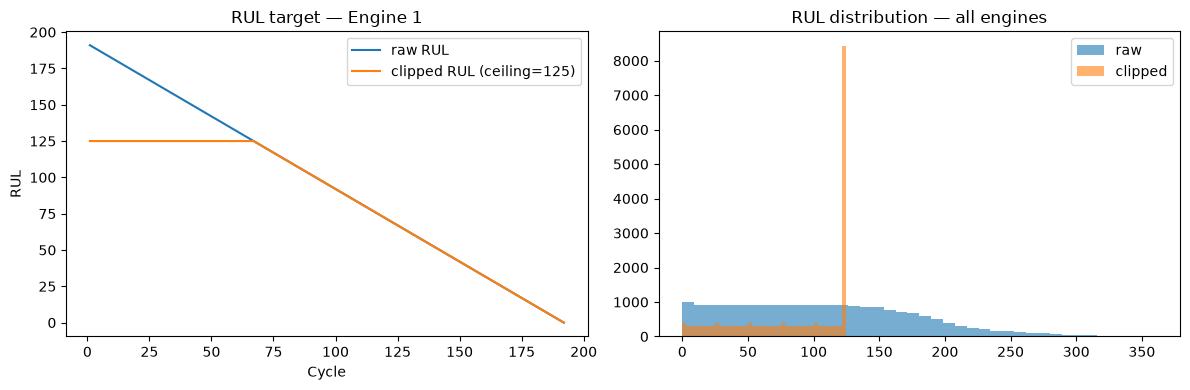

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_engine = train_labeled[train_labeled.unit_number == 1]
axes[0].plot(sample_engine['time_in_cycles'], sample_engine['RUL'], label='raw RUL')
axes[0].plot(sample_engine['time_in_cycles'], sample_engine['RUL_clipped'],
             label=f'clipped RUL (ceiling={RUL_CLIP})')
axes[0].set_xlabel('Cycle'); axes[0].set_ylabel('RUL'); axes[0].legend()
axes[0].set_title('RUL target — Engine 1')

axes[1].hist(train_labeled['RUL'], bins=40, alpha=0.6, label='raw')
axes[1].hist(train_labeled['RUL_clipped'], bins=40, alpha=0.6, label='clipped')
axes[1].set_title('RUL distribution — all engines'); axes[1].legend()
plt.tight_layout(); plt.show()

## Understand the test RUL format
`RUL_FD001.txt` gives exactly ONE ground-truth RUL value per test engine — the true remaining life at the point its (truncated) trajectory was cut off. It only applies to each engine's **last** observed row.

In [5]:
rul_df.head()

,unit_number,RUL
0,1,112
1,2,98
2,3,69
3,4,82
4,5,91


In [6]:
test_labeled = attach_test_rul(test_df, rul_df)
labeled_rows = test_labeled[test_labeled['RUL'].notna()]
print(f'{len(labeled_rows)} labeled rows out of {test_labeled.shape[0]} total '
      f'({test_labeled.unit_number.nunique()} engines)')
labeled_rows[['unit_number', 'time_in_cycles', 'RUL']].head()

[2026-10-09 06:44:04] INFO     | src.data.transformation | Attached test RUL to 100/100 engines (final-cycle rows only)
100 labeled rows out of 13096 total (100 engines)


,unit_number,time_in_cycles,RUL
30,1,31,112.0
79,2,49,98.0
205,3,126,69.0
311,4,106,82.0
409,5,98,91.0


## Engine-level train/validation split
Splitting by `unit_number` (not by row) guarantees no engine's trajectory is leaked across train and validation — see "Avoiding Data Leakage" in the README.

In [7]:
train_split, val_split = engine_train_val_split(train_labeled)

print('Train engines:', train_split.unit_number.nunique())
print('Val engines  :', val_split.unit_number.nunique())
overlap = set(train_split.unit_number) & set(val_split.unit_number)
print('Overlap (should be empty):', overlap)

[2026-10-09 06:44:04] INFO     | src.data.transformation | Engine-level split: 80 train engines / 20 val engines (20% held out)
Train engines: 80
Val engines  : 20
Overlap (should be empty): set()


## Persist RUL-labeled datasets

In [8]:
train_split.to_parquet(PROCESSED_DATA_DIR / f'train_{VARIANT}_rul_split_train.parquet', index=False)
val_split.to_parquet(PROCESSED_DATA_DIR / f'train_{VARIANT}_rul_split_val.parquet', index=False)
test_labeled.to_parquet(PROCESSED_DATA_DIR / f'test_{VARIANT}_rul_labeled.parquet', index=False)
print('Saved RUL-labeled train/val/test splits to data/processed/')

Saved RUL-labeled train/val/test splits to data/processed/


## Next
Continue to **05_feature_engineering.ipynb** to build rolling, lag, trend, and degradation features on top of these RUL-labeled splits.